# 4. Model Training — FashionMNIST MLP

**Practice 1: FashionMNIST Classification with PyTorch**

sử dụng `data.py` của Thành viên 2 và `model.py`  

## 4.1. Training workflow

Quy trình huấn luyện cho mỗi batch:

`Load batch → Move to device → zero_grad() → Forward → Loss → Backward → optimizer.step()`

- `Forward`: mô hình tạo logits cho 10 lớp FashionMNIST.
- `Loss`: `CrossEntropyLoss` đo sai lệch giữa logits và nhãn thật.
- `Backward`: Autograd tính gradient.
- `optimizer.step()`: Adam cập nhật trọng số mô hình.


In [6]:
from Practice_1.src.model import NeuralNetwork

test_model = NeuralNetwork()

print(test_model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [7]:
import importlib
import Practice_1.src.model as model_module

importlib.reload(model_module)

NeuralNetwork = model_module.NeuralNetwork

model = NeuralNetwork()

print("Import model thành công!")
print(model)

Import model thành công!
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)


In [8]:
from pathlib import Path
import csv
import random
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim


def find_repo_root(start: Path) -> Path:
    """Tìm thư mục gốc chứa Practice_1."""
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "Practice_1").is_dir():
            return candidate

    raise FileNotFoundError(
        "Không tìm thấy thư mục gốc repository chứa Practice_1. "
        "Hãy mở notebook từ repository UTH-Deep-Learning-nhom2."
    )


REPO_ROOT = find_repo_root(Path.cwd())

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from Practice_1.src.data import create_dataloaders
except (ImportError, ModuleNotFoundError) as exc:
    raise ImportError(
        "Không import được create_dataloaders từ Practice_1/src/data.py. "
        "Hãy kiểm tra phần Thành viên 2."
    ) from exc

try:
    from Practice_1.src.model import NeuralNetwork
except (ImportError, ModuleNotFoundError) as exc:
    raise ImportError(
        "Không import được NeuralNetwork từ Practice_1/src/model.py. "
        "Hãy kiểm tra phần Thành viên 3."
    ) from exc

DATA_DIR = REPO_ROOT / "data"
FIGURE_DIR = REPO_ROOT / "Practice_1" / "figures"
MODEL_DIR = REPO_ROOT / "Practice_1" / "models"
EXPERIMENT_DIR = REPO_ROOT / "Practice_1" / "experiments"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

print("Repository root :", REPO_ROOT)
print("Data directory  :", DATA_DIR)
print("Figure directory:", FIGURE_DIR)
print("Model directory :", MODEL_DIR)


Repository root : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2
Data directory  : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\data
Figure directory: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures
Model directory : D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models


## 4.2. Configuration and reproducibility

Cấu hình baseline của nhóm:

- Batch size: `64`
- Learning rate: `0.001`
- Optimizer: `Adam`
- Number of epochs: `10`
- Loss function: `CrossEntropyLoss`


In [9]:
SEED = 42
BATCH_SIZE = 64
LEARNING_RATE = 0.001
NUM_EPOCHS = 10

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device        :", device)
print("Batch size    :", BATCH_SIZE)
print("Learning rate :", LEARNING_RATE)
print("Epochs        :", NUM_EPOCHS)


Device        : cpu
Batch size    : 64
Learning rate : 0.001
Epochs        : 10


## 4.3. Load FashionMNIST DataLoaders

Dữ liệu được lấy từ hàm dùng chung data.py .  


In [10]:
(
    train_dataset,
    test_dataset,
    train_loader,
    test_loader,
) = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
)

images, labels = next(iter(train_loader))

print("Training samples :", len(train_dataset))
print("Test samples     :", len(test_dataset))
print("Training batches :", len(train_loader))
print("Test batches     :", len(test_loader))
print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)

assert images.ndim == 4, "Batch ảnh phải có 4 chiều."
assert images.shape[1:] == (1, 28, 28), "FashionMNIST phải có shape [N, 1, 28, 28]."
assert labels.ndim == 1, "Nhãn phải có shape [N]."


Training samples : 60000
Test samples     : 10000
Training batches : 938
Test batches     : 157
Image batch shape: torch.Size([64, 1, 28, 28])
Label batch shape: torch.Size([64])


## 4.4. Initialize the MLP model

Mô hình được import từ `Practice_1/src/model.py`. Kiến trúc dùng để huấn luyện và kiến trúc dùng để load checkpoint ở Thành viên 5 phải giống hoàn toàn.


In [11]:
model = NeuralNetwork().to(device)

with torch.no_grad():
    sample_logits = model(images.to(device))

print(model)
print("Input shape :", images.shape)
print("Output shape:", sample_logits.shape)

assert sample_logits.shape == (images.shape[0], 10), (
    "Output của mô hình phải có shape [batch_size, 10]."
)


NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)
Input shape : torch.Size([64, 1, 28, 28])
Output shape: torch.Size([64, 10])


## 4.5. Loss function and optimizer

- `CrossEntropyLoss` nhận trực tiếp logits và nhãn số nguyên từ `0` đến `9`.
- Không đặt `Softmax` trong lớp cuối của mô hình.
- Adam được dùng với learning rate `0.001` làm cấu hình baseline.


In [12]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE,
)

print("Loss function:", criterion)
print("Optimizer    :", optimizer.__class__.__name__)


Loss function: CrossEntropyLoss()
Optimizer    : Adam


## 4.6. Training function

Hàm dưới đây trả về lịch sử:

- `train_loss`: loss trung bình trên toàn bộ mẫu huấn luyện của mỗi epoch.
- `train_accuracy`: tỷ lệ dự đoán đúng trên tập huấn luyện của mỗi epoch.
- `epoch_time`: thời gian chạy của từng epoch.


In [13]:
def train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    device,
    num_epochs=10,
):
    history = {
        "epoch": [],
        "train_loss": [],
        "train_accuracy": [],
        "epoch_time": [],
    }

    total_start = time.perf_counter()

    for epoch in range(1, num_epochs + 1):
        epoch_start = time.perf_counter()
        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad(set_to_none=True)

            logits = model(images)
            loss = criterion(logits, labels)

            loss.backward()
            optimizer.step()

            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            correct += (logits.argmax(dim=1) == labels).sum().item()
            total += batch_size

        epoch_loss = running_loss / total
        epoch_accuracy = 100.0 * correct / total
        epoch_time = time.perf_counter() - epoch_start

        history["epoch"].append(epoch)
        history["train_loss"].append(epoch_loss)
        history["train_accuracy"].append(epoch_accuracy)
        history["epoch_time"].append(epoch_time)

        print(
            f"Epoch [{epoch:02d}/{num_epochs}] "
            f"- Loss: {epoch_loss:.4f} "
            f"- Train Accuracy: {epoch_accuracy:.2f}% "
            f"- Time: {epoch_time:.2f}s"
        )

    total_time = time.perf_counter() - total_start
    print(f"\nTraining completed in {total_time:.2f} seconds.")

    return history, total_time


## 4.7. Run training

  


In [14]:
history, total_training_time = train_model(
    model=model,
    train_loader=train_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    num_epochs=NUM_EPOCHS,
)


Epoch [01/10] - Loss: 0.5512 - Train Accuracy: 80.72% - Time: 17.17s
Epoch [02/10] - Loss: 0.3899 - Train Accuracy: 86.16% - Time: 16.19s
Epoch [03/10] - Loss: 0.3500 - Train Accuracy: 87.23% - Time: 15.89s
Epoch [04/10] - Loss: 0.3271 - Train Accuracy: 87.92% - Time: 15.98s
Epoch [05/10] - Loss: 0.3051 - Train Accuracy: 88.86% - Time: 15.89s
Epoch [06/10] - Loss: 0.2919 - Train Accuracy: 89.11% - Time: 15.88s
Epoch [07/10] - Loss: 0.2777 - Train Accuracy: 89.84% - Time: 15.90s
Epoch [08/10] - Loss: 0.2682 - Train Accuracy: 90.02% - Time: 15.89s
Epoch [09/10] - Loss: 0.2573 - Train Accuracy: 90.47% - Time: 15.84s
Epoch [10/10] - Loss: 0.2456 - Train Accuracy: 90.91% - Time: 16.06s

Training completed in 160.69 seconds.


## 4.8. Save training history

 

In [15]:
HISTORY_PATH = EXPERIMENT_DIR / "tv4_training_history.csv"

with HISTORY_PATH.open("w", newline="", encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow([
        "epoch",
        "train_loss",
        "train_accuracy",
        "epoch_time_seconds",
    ])

    for epoch, loss, accuracy, epoch_time in zip(
        history["epoch"],
        history["train_loss"],
        history["train_accuracy"],
        history["epoch_time"],
    ):
        writer.writerow([
            epoch,
            f"{loss:.6f}",
            f"{accuracy:.4f}",
            f"{epoch_time:.4f}",
        ])

print("Saved training history:", HISTORY_PATH)


Saved training history: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\experiments\tv4_training_history.csv


## 4.9. Plot and save training loss

Biểu đồ loss là một sản phẩm bắt buộc của Practice 1. Đường loss giảm cho thấy quá trình tối ưu đang cải thiện mô hình trên tập huấn luyện.


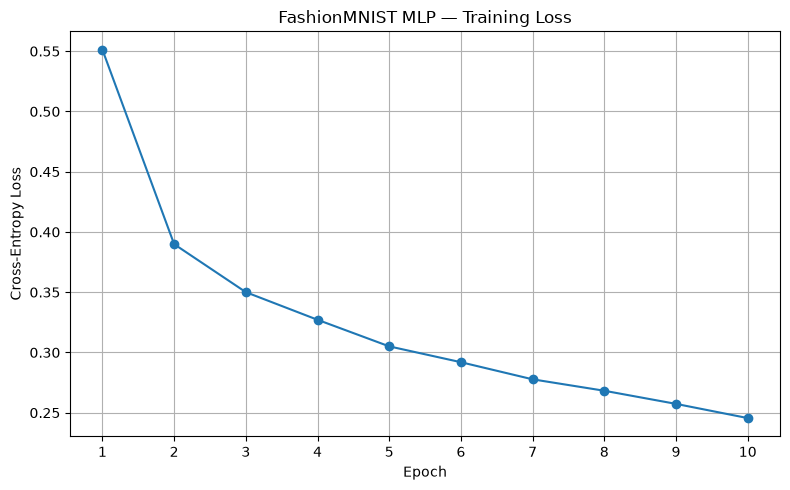

Saved loss graph: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\training_loss.png


In [16]:
LOSS_FIGURE_PATH = FIGURE_DIR / "training_loss.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    LOSS_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved loss graph:", LOSS_FIGURE_PATH)


## 4.10. Plot training accuracy

Training accuracy giúp kiểm tra mô hình có học trên tập train hay không. Đây không phải test accuracy; việc đánh giá trên tập test thuộc phần Thành viên 5.


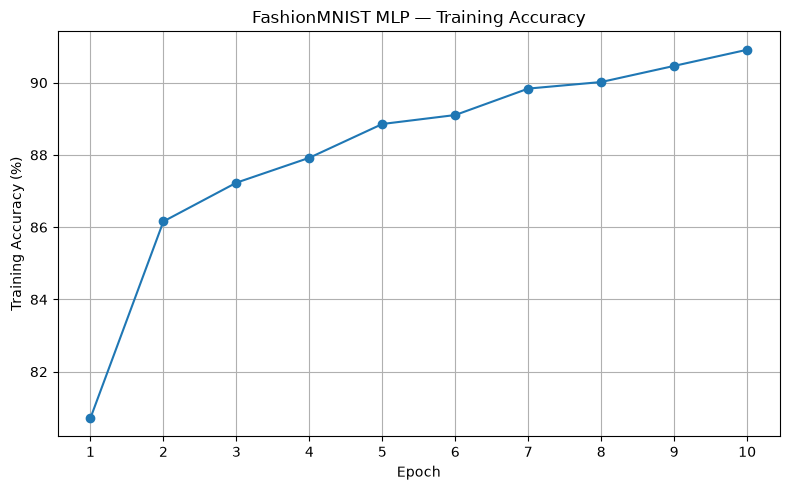

Saved accuracy graph: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\figures\training_accuracy.png


In [17]:
ACCURACY_FIGURE_PATH = FIGURE_DIR / "training_accuracy.png"

plt.figure(figsize=(8, 5))
plt.plot(
    history["epoch"],
    history["train_accuracy"],
    marker="o",
)
plt.title("FashionMNIST MLP — Training Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy (%)")
plt.xticks(history["epoch"])
plt.grid(True)
plt.tight_layout()

plt.savefig(
    ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()
print("Saved accuracy graph:", ACCURACY_FIGURE_PATH)


## 4.11. Save the trained model

Checkpoint được lưu **sau khi huấn luyện**. Thành viên 5 dùng đúng file này để tính test loss, test accuracy và hiển thị dự đoán.


In [18]:
MODEL_PATH = MODEL_DIR / "fashion_mnist_mlp_trained.pth"

torch.save(
    model.state_dict(),
    MODEL_PATH,
)

print("Saved trained model:", MODEL_PATH)
print("Checkpoint size (KB):", MODEL_PATH.stat().st_size / 1024)


Saved trained model: D:\GTVT-UTH\HK_He_2026\DEEP_LEARNING\UTH-Deep-Learning-nhom2\Practice_1\models\fashion_mnist_mlp_trained.pth
Checkpoint size (KB): 430.6064453125


## 4.12. Verify save/load

Cell này kiểm tra checkpoint có thể load lại bằng đúng kiến trúc `NeuralNetwork`. Hai mô hình phải tạo logits giống nhau trên cùng một batch.


In [19]:
reloaded_model = NeuralNetwork().to(device)

state_dict = torch.load(
    MODEL_PATH,
    map_location=device,
    weights_only=True,
)

reloaded_model.load_state_dict(state_dict)
reloaded_model.eval()
model.eval()

verification_images, _ = next(iter(train_loader))
verification_images = verification_images.to(device)

with torch.no_grad():
    original_logits = model(verification_images)
    reloaded_logits = reloaded_model(verification_images)

same_outputs = torch.allclose(
    original_logits,
    reloaded_logits,
    atol=1e-6,
)

print("Checkpoint loaded successfully:", same_outputs)
assert same_outputs, "Output sau khi load checkpoint không khớp model đã lưu."


Checkpoint loaded successfully: True


## 4.13. Training result analysis

Sau khi chạy notebook, cần nhận xét:

1. Loss ở epoch đầu và epoch cuối.
2. Loss có giảm đều hay dao động mạnh.
3. Training accuracy có tăng hay không.
4. Thời gian huấn luyện.
5. Chưa kết luận khả năng tổng quát hóa chỉ từ training loss; cần kết quả test của Thành viên 5.


In [20]:
first_loss = history["train_loss"][0]
final_loss = history["train_loss"][-1]
loss_reduction = first_loss - final_loss

first_accuracy = history["train_accuracy"][0]
final_accuracy = history["train_accuracy"][-1]

print("TRAINING SUMMARY")
print("-" * 50)
print(f"First epoch loss       : {first_loss:.4f}")
print(f"Final epoch loss       : {final_loss:.4f}")
print(f"Loss reduction         : {loss_reduction:.4f}")
print(f"First train accuracy   : {first_accuracy:.2f}%")
print(f"Final train accuracy   : {final_accuracy:.2f}%")
print(f"Total training time    : {total_training_time:.2f}s")
print(f"Saved checkpoint       : {MODEL_PATH.name}")
print(f"Saved loss figure      : {LOSS_FIGURE_PATH.name}")


TRAINING SUMMARY
--------------------------------------------------
First epoch loss       : 0.5512
Final epoch loss       : 0.2456
Loss reduction         : 0.3057
First train accuracy   : 80.72%
Final train accuracy   : 90.91%
Total training time    : 160.69s
Saved checkpoint       : fashion_mnist_mlp_trained.pth
Saved loss figure      : training_loss.png
